# When Do Diffusion Transformers Outperform U-Nets?

**Course:** UBC CPSC 440/550  
**Group:** Gunbir Baveja, Parvin Aliyeva, Arshvir Sandhu

## Goal
Compare a standard convolutional U-Net and a small Diffusion Transformer (DiT) as denoisers in
a DDPM-style diffusion model trained on CIFAR-10. We ask:
1. Does a DiT outperform a U-Net at **modest scale** (matched training budget + model size)?
2. Does any advantage become more pronounced under **structured corruptions** (patch masking,
   localized occlusions) that require global information integration?

## Notebook Structure
1. Setup & Imports  
2. Config & Hyperparameters  
3. Data Loading & Augmentation  
4. Diffusion Utilities (forward process, noise schedule)  
5. Model Definitions (U-Net + DiT)  
6. Training Loop  
7. Evaluation — Standard Diffusion (loss curves, optional FID)  
8. Structured Corruption Experiments  
9. Ablation Studies (patch size / depth)  
10. Visualizations & Results

In [ ]:
# ── Installs (run once) ──────────────────────────────────────────────────────
!pip install -q einops timm clean-fid torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.8 MB/s eta 0:00:00


In [ ]:
import os, math, copy, random, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# For FID (optional — comment out if too slow on free Colab)
# from cleanfid import fid

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ── Global Config ─────────────────────────────────────────────────────────────
# class CFG:
#     # Data
#     image_size   = 32          # CIFAR-10 native resolution
#     channels     = 3

#     # Diffusion
#     T            = 1000        # total diffusion timesteps
#     beta_start   = 1e-4
#     beta_end     = 0.02
#     schedule     = "linear"    # "linear" | "cosine"

#     # Training
#     batch_size   = 128
#     lr           = 2e-4
#     num_epochs   = 1         # increase for better results; ~200-300 for publication quality
#     grad_clip    = 1.0
#     ema_decay    = 0.9999

#     # U-Net
#     unet_base_channels = 64
#     unet_channel_mults = (1, 2, 4)   # keeps model small

#     # DiT
#     dit_patch_size  = 4        # pixels per patch (ablation: try 2, 4, 8)
#     dit_dim         = 256
#     dit_depth       = 6        # number of transformer blocks (ablation: try 4, 6, 8)
#     dit_heads       = 8
#     dit_mlp_ratio   = 4.0

#     # Structured corruption experiment
#     mask_patch_size = 8        # size of masked patches (in pixels)
#     mask_ratio      = 0.5      # fraction of image masked

#     # Logging
#     log_every    = 10          # epochs
#     sample_every = 20
#     save_dir     = "checkpoints"

# UPDATE: changed to make it faster.
class CFG:
    image_size   = 32
    channels     = 3
    T            = 500
    beta_start   = 1e-4
    beta_end     = 0.02
    schedule     = "linear"
    batch_size   = 128
    lr           = 2e-4
    num_epochs   = 40
    grad_clip    = 1.0
    ema_decay    = 0.9999
    unet_base_channels = 40
    unet_channel_mults = (1, 2, 2)
    dit_patch_size  = 4
    dit_dim         = 128
    dit_depth       = 4
    dit_heads       = 4
    dit_mlp_ratio   = 4.0
    mask_patch_size = 8
    mask_ratio      = 0.5
    log_every    = 5
    sample_every = 10
    save_dir     = "checkpoints"

Path(CFG.save_dir).mkdir(exist_ok=True)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

## 3. Data Loading

We use **CIFAR-10** (32×32 RGB). Standard augmentation: random horizontal flip + normalization to [-1, 1].

In [ ]:
def get_dataloaders(batch_size=CFG.batch_size):
    transform = T.Compose([
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),   # maps to [-1, 1]
    ])
    train_ds = CIFAR10(root="./data", train=True,  download=True, transform=transform)
    test_ds  = CIFAR10(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, test_loader

train_loader, test_loader = get_dataloaders()
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 390 | Test batches: 79


## 4. Diffusion Utilities

We implement a standard discrete-time DDPM forward process:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

The model is trained to predict the noise $\varepsilon$ with the objective:

$$\mathcal{L}(\theta) = \mathbb{E}_{x_0, \varepsilon, t} \left\| \varepsilon - f_\theta(x_t, t) \right\|_2^2$$

We support both **linear** and **cosine** noise schedules.

In [ ]:
class DiffusionSchedule:
    def __init__(self, cfg: CFG):
        self.T = cfg.T
        if cfg.schedule == "linear":
            betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.T)
        elif cfg.schedule == "cosine":
            # Improved DDPM cosine schedule
            steps = cfg.T + 1
            s = 0.008
            x = torch.linspace(0, cfg.T, steps)
            alphas_cumprod = torch.cos(((x / cfg.T) + s) / (1 + s) * math.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]
            betas = torch.clamp(betas, 0, 0.999)
        else:
            raise ValueError(f"Unknown schedule: {cfg.schedule}")

        alphas            = 1.0 - betas
        alphas_cumprod    = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.register = lambda name, val: setattr(self, name, val.to(DEVICE))
        self.register("betas", betas)
        self.register("alphas_cumprod", alphas_cumprod)
        self.register("sqrt_alphas_cumprod", alphas_cumprod.sqrt())
        self.register("sqrt_one_minus_alphas_cumprod", (1 - alphas_cumprod).sqrt())
        self.register("posterior_variance",
                      betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod))

    def q_sample(self, x0, t, noise=None):
        """Forward process: sample x_t given x_0."""
        if noise is None:
            noise = torch.randn_like(x0)
        s1 = self.sqrt_alphas_cumprod[t][:, None, None, None]
        s2 = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return s1 * x0 + s2 * noise, noise

    @torch.no_grad()
    def p_sample(self, model, x, t_idx):
        """Single reverse step."""
        t_tensor = torch.full((x.shape[0],), t_idx, device=DEVICE, dtype=torch.long)
        pred_noise = model(x, t_tensor)
        beta_t     = self.betas[t_idx]
        sqrt_recip = (1.0 / (1.0 - self.betas[t_idx]).sqrt())
        # Compute mean
        alpha_t    = 1.0 - beta_t
        ac         = self.alphas_cumprod[t_idx]
        mean = (1 / alpha_t.sqrt()) * (x - (beta_t / (1 - ac).sqrt()) * pred_noise)
        if t_idx == 0:
            return mean
        noise = torch.randn_like(x)
        return mean + self.posterior_variance[t_idx].sqrt() * noise

    @torch.no_grad()
    def sample(self, model, n_samples, img_shape):
        """Full reverse chain sampling."""
        model.eval()
        x = torch.randn(n_samples, *img_shape, device=DEVICE)
        for t in tqdm(reversed(range(self.T)), desc="Sampling", total=self.T, leave=False):
            x = self.p_sample(model, x, t)
        return x.clamp(-1, 1)

schedule = DiffusionSchedule(CFG)
print("Diffusion schedule ready.")

Diffusion schedule ready.


## 5. Model Definitions

### 5a. U-Net (convolutional baseline)
Standard encoder–decoder with skip connections and sinusoidal time embeddings.  
Strong **locality bias** — convolutional kernels capture spatially local patterns.

### 5b. Diffusion Transformer (DiT)
Splits the image into non-overlapping patches and processes them with multi-head self-attention.  
Patch size controls the trade-off between resolution and global context range.

In [ ]:
# ── Shared: Sinusoidal timestep embedding ────────────────────────────────────
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

def num_groups(channels, target=8):
    """Find largest divisor of `channels` that is <= target."""
    for g in range(target, 0, -1):
        if channels % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch))
        self.block1 = nn.Sequential(
            nn.GroupNorm(num_groups(in_ch),  in_ch),  nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(num_groups(out_ch), out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(num_groups(ch), ch)
        self.attn = nn.MultiheadAttention(ch, num_heads=4, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H * W).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).reshape(B, C, H, W)

In [ ]:
class UNet(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        base  = cfg.unet_base_channels
        mults = cfg.unet_channel_mults
        dims  = [base * m for m in mults]   # e.g. [64, 128, 256]
        t_dim = base * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base),
            nn.Linear(base, t_dim), nn.GELU(),
            nn.Linear(t_dim, t_dim),
        )

        # ── Encoder ──────────────────────────────────────────────────────────
        # One block per level transition: dims[i] → dims[i+1], with downsample
        # Skips saved at each level's OUTPUT channels (before downsample)
        self.init_conv = nn.Conv2d(cfg.channels, dims[0], 3, padding=1)

        self.down_blocks = nn.ModuleList()
        self.downsamples  = nn.ModuleList()
        skip_channels = []          # track what each skip actually contains
        in_ch = dims[0]
        for out_ch in dims[1:]:     # transitions: 64→128, 128→256
            self.down_blocks.append(nn.ModuleList([
                ResBlock(in_ch, out_ch, t_dim),
                ResBlock(out_ch, out_ch, t_dim),
            ]))
            skip_channels.append(out_ch)   # skip will have out_ch channels
            self.downsamples.append(
                nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1))
            in_ch = out_ch
        # in_ch == dims[-1] == 256

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.mid_block1 = ResBlock(in_ch, in_ch, t_dim)
        self.mid_attn   = AttentionBlock(in_ch)
        self.mid_block2 = ResBlock(in_ch, in_ch, t_dim)

        # ── Decoder ──────────────────────────────────────────────────────────
        # Mirror encoder: one up-block per skip, in reverse order
        self.up_blocks   = nn.ModuleList()
        self.upsamples   = nn.ModuleList()
        for skip_ch in reversed(skip_channels):   # 256, 128
            out_ch = skip_ch // (mults[1] // mults[0]) if skip_ch > dims[0] else dims[0]
            # Simpler: just halve in_ch as the target output
            target_ch = in_ch // 2 if in_ch > dims[0] else dims[0]
            self.upsamples.append(
                nn.ConvTranspose2d(in_ch, target_ch, 4, stride=2, padding=1))
            # After upsample we have target_ch; concat with skip_ch gives target_ch + skip_ch
            self.up_blocks.append(nn.ModuleList([
                ResBlock(target_ch + skip_ch, target_ch, t_dim),
                ResBlock(target_ch, target_ch, t_dim),
            ]))
            in_ch = target_ch
        # in_ch == dims[0] == 64

        self.out_norm = nn.GroupNorm(num_groups(in_ch), in_ch)
        self.out_conv = nn.Conv2d(in_ch, cfg.channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.init_conv(x)

        # Encoder
        skips = []
        for (res1, res2), down in zip(self.down_blocks, self.downsamples):
            x = res1(x, t_emb)
            x = res2(x, t_emb)
            skips.append(x)        # save before downsample
            x = down(x)

        # Bottleneck
        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        # Decoder
        for (res1, res2), up in zip(self.up_blocks, self.upsamples):
            x = up(x)
            x = torch.cat([x, skips.pop()], dim=1)   # skips.pop() = LIFO = correct level
            x = res1(x, t_emb)
            x = res2(x, t_emb)

        return self.out_conv(F.silu(self.out_norm(x)))


# Sanity check
_unet = UNet(CFG).to(DEVICE)
_x = torch.randn(2, CFG.channels, CFG.image_size, CFG.image_size, device=DEVICE)
_t = torch.randint(0, CFG.T, (2,), device=DEVICE)
out = _unet(_x, _t)
print("U-Net output shape:", out.shape)   # expect torch.Size([2, 3, 32, 32])
assert out.shape == _x.shape, f"Shape mismatch: {out.shape} vs {_x.shape}"
print("U-Net sanity check passed.")
del _unet, out

U-Net output shape: torch.Size([2, 3, 32, 32])
U-Net sanity check passed.


In [ ]:
# ── Diffusion Transformer (DiT) ───────────────────────────────────────────────
class DiTBlock(nn.Module):
    """Transformer block with adaLN-Zero conditioning on timestep."""
    def __init__(self, dim, heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_hidden), nn.GELU(),
            nn.Linear(mlp_hidden, dim),
        )
        # adaLN-Zero: predict scale/shift/gate from time embedding
        self.adaLN = nn.Sequential(nn.SiLU(),
                                   nn.Linear(dim, 6 * dim, bias=True))
        nn.init.zeros_(self.adaLN[-1].weight)
        nn.init.zeros_(self.adaLN[-1].bias)

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN(c).chunk(6, dim=-1)

        # Self-attention with adaLN
        h = self.norm1(x) * (1 + scale_msa.unsqueeze(1)) + shift_msa.unsqueeze(1)
        attn_out, _ = self.attn(h, h, h)
        x = x + gate_msa.unsqueeze(1) * attn_out

        # MLP with adaLN
        h = self.norm2(x) * (1 + scale_mlp.unsqueeze(1)) + shift_mlp.unsqueeze(1)
        x = x + gate_mlp.unsqueeze(1) * self.mlp(h)
        return x


class DiT(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        p    = cfg.dit_patch_size
        dim  = cfg.dit_dim
        img  = cfg.image_size
        n_patches = (img // p) ** 2

        # Patch embedding
        self.patch_embed = nn.Sequential(
            Rearrange("b c (h p1) (w p2) -> b (h w) (p1 p2 c)", p1=p, p2=p),
            nn.LayerNorm(p * p * cfg.channels),
            nn.Linear(p * p * cfg.channels, dim),
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Timestep conditioning
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(dim),
            nn.Linear(dim, dim * 4), nn.GELU(),
            nn.Linear(dim * 4, dim),
        )

        self.blocks = nn.ModuleList([
            DiTBlock(dim, cfg.dit_heads, cfg.dit_mlp_ratio)
            for _ in range(cfg.dit_depth)
        ])

        self.norm_out = nn.LayerNorm(dim)
        self.head     = nn.Linear(dim, p * p * cfg.channels)
        self.unpatch  = Rearrange("b (h w) (p1 p2 c) -> b c (h p1) (w p2)",
                                  h=img//p, w=img//p, p1=p, p2=p, c=cfg.channels)
        self._init_weights()

    def _init_weights(self):
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)

    def forward(self, x, t):
        c = self.time_mlp(t)
        x = self.patch_embed(x) + self.pos_embed
        for blk in self.blocks:
            x = blk(x, c)
        x = self.norm_out(x)
        x = self.head(x)
        return self.unpatch(x)


# Sanity check
_dit = DiT(CFG).to(DEVICE)
print("DiT output shape:", _dit(_x, _t).shape)
del _dit

DiT output shape: torch.Size([2, 3, 32, 32])


In [ ]:
class EMA:
    """Exponential Moving Average of model weights for stable sampling."""
    def __init__(self, model, decay=CFG.ema_decay):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()

    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.data.mul_(self.decay).add_(m.data, alpha=1 - self.decay)

    def get_model(self):
        return self.shadow

## 6. Training Loop

Both models are trained with **identical** hyperparameters (optimizer, lr, epochs, batch size)
to ensure a fair comparison. We log training loss and optionally validation loss every few epochs.

In [ ]:
def train(model, schedule, loader, cfg: CFG, model_name="model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
    ema       = EMA(model)
    losses    = []

    for epoch in range(1, cfg.num_epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, _ in tqdm(loader, desc=f"[{model_name}] Epoch {epoch}/{cfg.num_epochs}",
                          leave=False):
            x0 = x0.to(DEVICE)
            t  = torch.randint(0, cfg.T, (x0.shape[0],), device=DEVICE)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                xt, noise = schedule.q_sample(x0, t)
                pred      = model(xt, t)
                loss      = F.mse_loss(pred, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer); scaler.update()
            ema.update(model)
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        if epoch % cfg.log_every == 0:
            print(f"[{model_name}] Epoch {epoch:4d} | Loss: {avg_loss:.4f}")

        if epoch % cfg.sample_every == 0:
            ckpt_path = f"{cfg.save_dir}/{model_name}_epoch{epoch}.pt"
            torch.save({"model": model.state_dict(),
                        "ema":   ema.shadow.state_dict(),
                        "epoch": epoch}, ckpt_path)

    return losses, ema

In [ ]:
# ── Instantiate models ────────────────────────────────────────────────────────
unet = UNet(CFG).to(DEVICE)
dit  = DiT(CFG).to(DEVICE)

unet_params = sum(p.numel() for p in unet.parameters()) / 1e6
dit_params  = sum(p.numel() for p in dit.parameters())  / 1e6
print(f"U-Net params: {unet_params:.2f}M  |  DiT params: {dit_params:.2f}M")

U-Net params: 1.30M  |  DiT params: 1.34M


In [ ]:

# Adjust CFG.dit_dim / unet_base_channels above until these are roughly equal

#UPDATED:
# ── Compile (skip first-epoch slowdown, ~20-40% faster after) ────────────────
unet = torch.compile(unet)
dit  = torch.compile(dit)

# ── Train ─────────────────────────────────────────────────────────────────────
unet_losses, unet_ema = train(unet, schedule, train_loader, CFG, model_name="unet")
dit_losses,  dit_ema  = train(dit,  schedule, train_loader, CFG, model_name="dit")

/tmp/ipykernel_4328/2898631782.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


[unet] Epoch 1/40:   0%|          | 0/390 [00:00<?, ?it/s]

/tmp/ipykernel_4328/2898631782.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_4328/2898631782.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


[unet] Epoch 2/40:   0%|          | 0/390 [00:00<?, ?it/s]

[unet] Epoch 3/40:   0%|          | 0/390 [00:00<?, ?it/s]

...

[dit] Epoch 38/40:   0%|          | 0/390 [00:00<?, ?it/s]

[dit] Epoch 39/40:   0%|          | 0/390 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba1943cf920>Exception ignored in: 
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ba1943cf920>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
    if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive(): 
           ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

[dit] Epoch 40/40:   0%|          | 0/390 [00:00<?, ?it/s]

[dit] Epoch   40 | Loss: 0.0791


## 7. Evaluation — Standard Diffusion

We compare:
- **Training loss curves** over epochs
- **Visual sample quality** from the EMA models
- **FID score** (if compute allows) using `clean-fid`

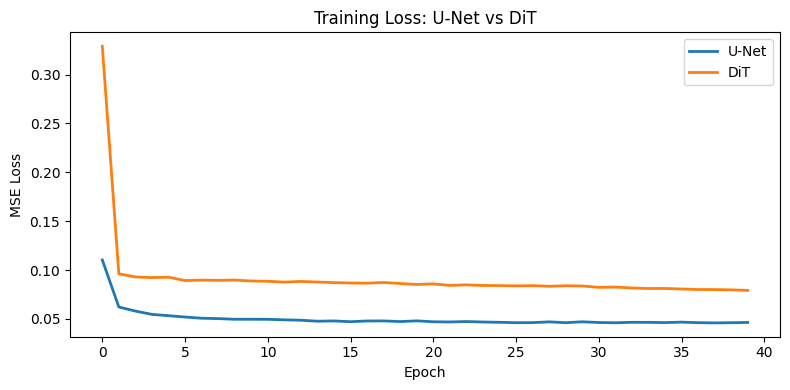

In [ ]:
def plot_loss_curves(unet_losses, dit_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(unet_losses, label="U-Net",  linewidth=2)
    plt.plot(dit_losses,  label="DiT",    linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Training Loss: U-Net vs DiT")
    plt.legend(); plt.tight_layout()
    plt.savefig("loss_curves.png", dpi=150)
    plt.show()

plot_loss_curves(unet_losses, dit_losses)

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

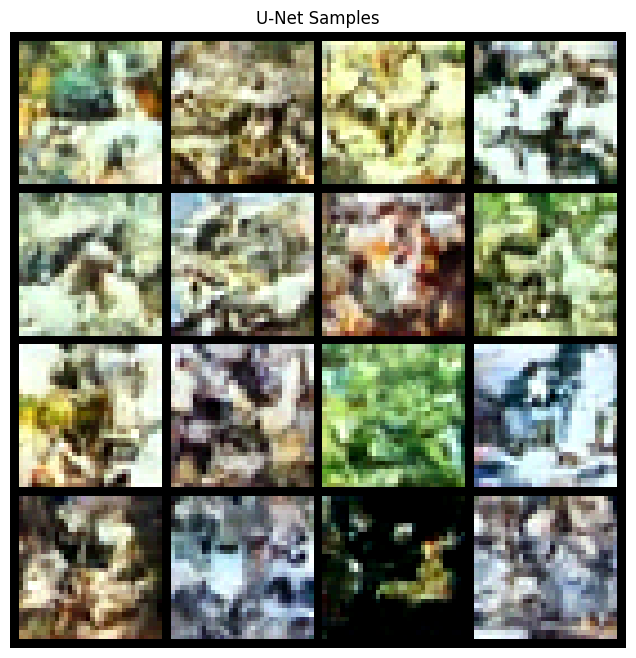

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

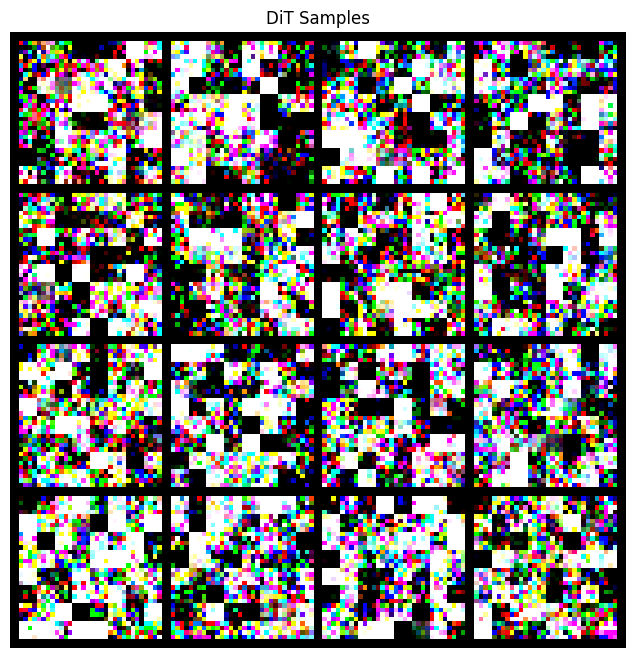

In [ ]:
def denorm(x):
    """[-1,1] → [0,1]"""
    return (x * 0.5 + 0.5).clamp(0, 1)

def show_samples(model, schedule, n=16, title="Samples"):
    samples = schedule.sample(model, n_samples=n,
                              img_shape=(CFG.channels, CFG.image_size, CFG.image_size))
    grid = torchvision.utils.make_grid(denorm(samples), nrow=int(n**0.5))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.title(title); plt.axis("off")
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

show_samples(unet_ema.get_model(), schedule, title="U-Net Samples")
show_samples(dit_ema.get_model(),  schedule, title="DiT Samples")

In [ ]:
# ── Optional FID ─────────────────────────────────────────────────────────────
# Uncomment if running on a GPU with enough memory/time.
# from cleanfid import fid as clean_fid
#
def compute_fid(model, schedule, n_samples=2048, tmp_dir="fid_tmp"):
    os.makedirs(tmp_dir, exist_ok=True)
    samples = schedule.sample(model, n_samples=n_samples,
                              img_shape=(CFG.channels, CFG.image_size, CFG.image_size))
    for i, img in enumerate(denorm(samples)):
        torchvision.utils.save_image(img, f"{tmp_dir}/{i:05d}.png")
    score = clean_fid.compute_fid(tmp_dir, dataset_name="cifar10", dataset_res=32,
                                  dataset_split="train", device=DEVICE)
    print(f"FID: {score:.2f}")
    return score

In [ ]:
unet_fid = compute_fid(unet_ema.get_model(), schedule, n_samples=2048)
dit_fid  = compute_fid(dit_ema.get_model(),  schedule, n_samples=2048)

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

NameError: name 'clean_fid' is not defined

## 8. Structured Corruption Experiments

**Hypothesis:** DiT's global attention provides a larger advantage when reconstruction
requires integrating non-local context.

We corrupt test images by **masking contiguous patches** (e.g., 50% of 8×8 blocks),
then ask each denoiser to recover them starting from a noisy version of the masked image.
We measure per-pixel MSE between the denoised output and the clean original.

In [ ]:
def apply_patch_mask(x, patch_size=CFG.mask_patch_size, mask_ratio=CFG.mask_ratio):
    """
    Randomly mask contiguous square patches.
    x: (B, C, H, W) in [-1, 1]
    Returns masked image and binary mask (1 = masked).
    """
    B, C, H, W = x.shape
    n_ph = H // patch_size
    n_pw = W // patch_size
    n_patches = n_ph * n_pw
    n_mask = int(n_patches * mask_ratio)

    mask = torch.zeros(B, 1, H, W, device=x.device)
    for b in range(B):
        idx = torch.randperm(n_patches)[:n_mask]
        for i in idx:
            r, c = divmod(i.item(), n_pw)
            mask[b, :, r*patch_size:(r+1)*patch_size,
                         c*patch_size:(c+1)*patch_size] = 1.0

    x_masked = x * (1 - mask)   # zero out masked regions
    return x_masked, mask


def corruption_eval(model, loader, schedule, n_batches=10):
    """
    For each batch: corrupt → add noise at t=T//2 → denoise one step → measure MSE.
    Returns mean MSE on masked vs unmasked regions separately.
    """
    model.eval()
    masked_mse_list, unmasked_mse_list = [], []
    t_eval = torch.tensor([CFG.T // 2], device=DEVICE)

    with torch.no_grad():
        for i, (x0, _) in enumerate(loader):
            if i >= n_batches: break
            x0 = x0.to(DEVICE)
            x_masked, mask = apply_patch_mask(x0)

            t_batch = t_eval.repeat(x0.shape[0])
            xt, noise = schedule.q_sample(x_masked, t_batch)
            pred_noise = model(xt, t_batch)

            # Reconstruct x0 estimate
            ac  = schedule.alphas_cumprod[t_eval[0]]
            x0_hat = (xt - (1 - ac).sqrt() * pred_noise) / ac.sqrt()

            err = (x0_hat - x0) ** 2
            masked_mse_list.append(  (err * mask).sum()       / mask.sum())
            unmasked_mse_list.append((err * (1 - mask)).sum() / (1 - mask).sum())

    return (torch.stack(masked_mse_list).mean().item(),
            torch.stack(unmasked_mse_list).mean().item())


unet_m, unet_u = corruption_eval(unet_ema.get_model(), test_loader, schedule)
dit_m,  dit_u  = corruption_eval(dit_ema.get_model(),  test_loader, schedule)

print(f"{'Model':<8} | {'Masked MSE':>12} | {'Unmasked MSE':>14}")
print("-" * 40)
print(f"{'U-Net':<8} | {unet_m:>12.5f} | {unet_u:>14.5f}")
print(f"{'DiT':<8} | {dit_m:>12.5f} | {dit_u:>14.5f}")

Model    |   Masked MSE |   Unmasked MSE
----------------------------------------
U-Net    |      0.75362 |        0.25989
DiT      |      1.46161 |        0.81794


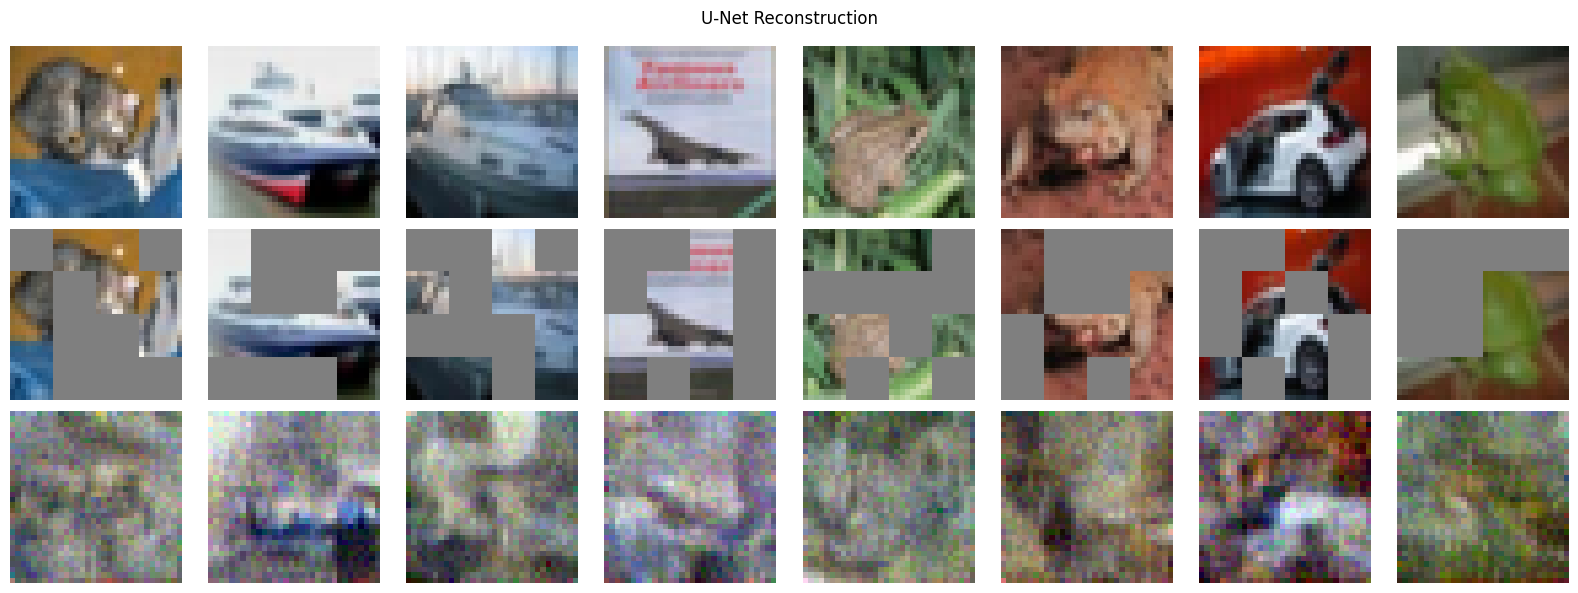

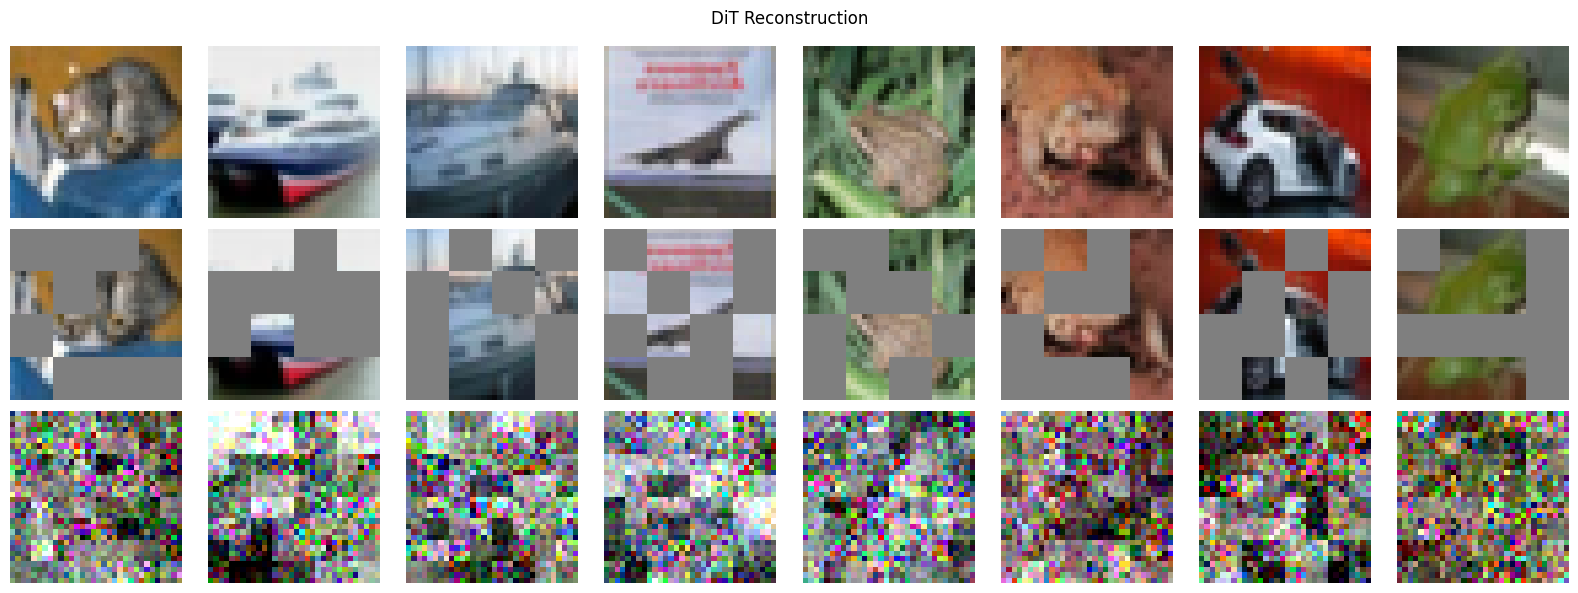

In [ ]:
def visualize_corruption(model, schedule, loader, title="Reconstruction"):
    model.eval()
    x0, _ = next(iter(loader))
    x0 = x0[:8].to(DEVICE)
    x_masked, mask = apply_patch_mask(x0)

    t_batch = torch.full((8,), CFG.T // 2, device=DEVICE)
    xt, _   = schedule.q_sample(x_masked, t_batch)
    with torch.no_grad():
        pred_noise = model(xt, t_batch)
    ac    = schedule.alphas_cumprod[CFG.T // 2]
    x0_hat = ((xt - (1 - ac).sqrt() * pred_noise) / ac.sqrt()).clamp(-1, 1)

    rows = [denorm(x0), denorm(x_masked), denorm(x0_hat)]
    labels = ["Original", "Masked Input", "Reconstruction"]
    fig, axes = plt.subplots(3, 8, figsize=(16, 6))
    for r, (row, label) in enumerate(zip(rows, labels)):
        for c, img in enumerate(row):
            axes[r, c].imshow(img.permute(1, 2, 0).cpu())
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(label, fontsize=10, rotation=90)
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

visualize_corruption(unet_ema.get_model(), schedule, test_loader, title="U-Net Reconstruction")
visualize_corruption(dit_ema.get_model(),  schedule, test_loader, title="DiT Reconstruction")

## 9. Ablation Studies

We vary **patch size** and **model depth** on the DiT to understand which aspects of the
architecture drive performance.

| Patch size | Effect |
|---|---|
| 2 | More patches, finer locality, higher compute |
| 4 | Default |
| 8 | Fewer patches, stronger global bias |

| Depth | Effect |
|---|---|
| 4 | Shallow — limited global composition |
| 6 | Default |
| 8 | Deeper — more expressive |

In [ ]:
def run_ablation(patch_sizes=[2, 4, 8], depths=[4, 6, 8],
                 epochs=50, loader=train_loader):
    results = {}

    # Patch size ablation (fixed depth = CFG.dit_depth)
    for ps in patch_sizes:
        cfg_abl = copy.copy(CFG)
        cfg_abl.dit_patch_size = ps
        cfg_abl.num_epochs = epochs
        model = DiT(cfg_abl).to(DEVICE)
        losses, ema = train(model, schedule, loader, cfg_abl,
                            model_name=f"dit_patch{ps}")
        m_mse, u_mse = corruption_eval(ema.get_model(), test_loader, schedule)
        results[f"patch_{ps}"] = {"final_loss": losses[-1],
                                   "masked_mse": m_mse, "unmasked_mse": u_mse}

    # Depth ablation (fixed patch size = CFG.dit_patch_size)
    for d in depths:
        cfg_abl = copy.copy(CFG)
        cfg_abl.dit_depth = d
        cfg_abl.num_epochs = epochs
        model = DiT(cfg_abl).to(DEVICE)
        losses, ema = train(model, schedule, loader, cfg_abl,
                            model_name=f"dit_depth{d}")
        m_mse, u_mse = corruption_eval(ema.get_model(), test_loader, schedule)
        results[f"depth_{d}"] = {"final_loss": losses[-1],
                                  "masked_mse": m_mse, "unmasked_mse": u_mse}

    return results

# Uncomment to run (takes time):
ablation_results = run_ablation()
import json; print(json.dumps(ablation_results, indent=2))

/tmp/ipykernel_4328/2898631782.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


[dit_patch2] Epoch 1/50:   0%|          | 0/390 [00:00<?, ?it/s]

/tmp/ipykernel_4328/2898631782.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


[dit_patch2] Epoch 2/50:   0%|          | 0/390 [00:00<?, ?it/s]

[dit_patch2] Epoch 3/50:   0%|          | 0/390 [00:00<?, ?it/s]

...

[dit_depth8] Epoch 47/50:   0%|          | 0/390 [00:00<?, ?it/s]

[dit_depth8] Epoch 48/50:   0%|          | 0/390 [00:00<?, ?it/s]

[dit_depth8] Epoch 49/50:   0%|          | 0/390 [00:00<?, ?it/s]

[dit_depth8] Epoch 50/50:   0%|          | 0/390 [00:00<?, ?it/s]

[dit_depth8] Epoch   50 | Loss: 0.3533
{
  "patch_2": {
    "final_loss": 0.16020024159015753,
    "masked_mse": 1.7760416269302368,
    "unmasked_mse": 1.1095879077911377
  },
  "patch_4": {
    "final_loss": 0.07858210014991271,
    "masked_mse": 1.1815645694732666,
    "unmasked_mse": 0.565739095211029
  },
  "patch_8": {
    "final_loss": 0.35296159485975903,
    "masked_mse": 3.6566810607910156,
    "unmasked_mse": 2.901372194290161
  },
  "depth_4": {
    "final_loss": 0.3532724351455004,
    "masked_mse": 3.6401238441467285,
    "unmasked_mse": 2.8986995220184326
  },
  "depth_6": {
    "final_loss": 0.3532347491154304,
    "masked_mse": 3.6596367359161377,
    "unmasked_mse": 2.893416404724121
  },
  "depth_8": {
    "final_loss": 0.3532904585966697,
    "masked_mse": 3.671469211578369,
    "unmasked_mse": 2.908360004425049
  }
}


## 10. Results & Visualizations

Populate this section after experiments finish. Suggested structure for the paper:

- **Table 1:** Final training loss + FID (if available) for U-Net vs DiT
- **Table 2:** Masked vs Unmasked MSE under structured corruption
- **Table 3:** Ablation results (patch size / depth)
- **Figure 1:** Loss curves
- **Figure 2:** Random samples (U-Net vs DiT side by side)
- **Figure 3:** Corruption reconstruction grid
- **Figure 4:** Ablation bar charts

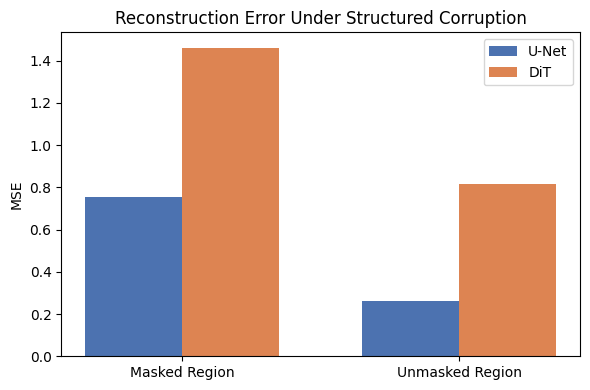

In [ ]:
def plot_corruption_comparison(unet_m, unet_u, dit_m, dit_u):
    labels = ["Masked Region", "Unmasked Region"]
    unet_vals = [unet_m, unet_u]
    dit_vals  = [dit_m,  dit_u]

    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - w/2, unet_vals, w, label="U-Net",  color="#4C72B0")
    ax.bar(x + w/2, dit_vals,  w, label="DiT",    color="#DD8452")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("MSE"); ax.set_title("Reconstruction Error Under Structured Corruption")
    ax.legend(); plt.tight_layout()
    plt.savefig("corruption_comparison.png", dpi=150)
    plt.show()

plot_corruption_comparison(unet_m, unet_u, dit_m, dit_u)